1. Title and objective

# CICIoMT2024 - Binary Classification Baselines

## Objective
This notebook develops baseline machine learning models for binary intrusion detection on the CICIoMT2024 dataset. The binary task is defined as:

- 0 = Benign
- 1 = Attack

The notebook compares a linear baseline and tree-based models, evaluates their performance using class-sensitive metrics, and discusses the impact of severe class imbalance on model behaviour.

2. Imports

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve
)

3. Display settings

In [2]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 1000)

plt.style.use("default")
sns.set_theme(style="whitegrid")

4. Load processed datasets

## Load processed binary datasets
Tree-based models use the broader unscaled feature set, while the logistic regression baseline uses the scaled linear-model feature set.

In [3]:
PROCESSED_DIR = Path("../data/processed")

X_train_tree = pd.read_csv(PROCESSED_DIR / "X_train_tree_binary.csv")
X_test_tree = pd.read_csv(PROCESSED_DIR / "X_test_tree_binary.csv")
y_train = pd.read_csv(PROCESSED_DIR / "y_train_binary.csv").squeeze("columns")
y_test = pd.read_csv(PROCESSED_DIR / "y_test_binary.csv").squeeze("columns")

X_train_linear = pd.read_csv(PROCESSED_DIR / "X_train_linear_binary_scaled.csv")
X_test_linear = pd.read_csv(PROCESSED_DIR / "X_test_linear_binary_scaled.csv")

print("Tree train:", X_train_tree.shape)
print("Tree test:", X_test_tree.shape)
print("Linear train:", X_train_linear.shape)
print("Linear test:", X_test_linear.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Tree train: (2708250, 73)
Tree test: (677063, 73)
Linear train: (2708250, 53)
Linear test: (677063, 53)
y_train: (2708250,)
y_test: (677063,)


5. Confirm target distribution

In [4]:
print("Training target distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Training target distribution:
target_binary
1    2682154
0      26096
Name: count, dtype: int64
target_binary
1    0.990364
0    0.009636
Name: proportion, dtype: float64

Test target distribution:
target_binary
1    670539
0      6524
Name: count, dtype: int64
target_binary
1    0.990364
0    0.009636
Name: proportion, dtype: float64


6. Helper functions

## Evaluation helpers

In [5]:
def evaluate_binary_model(model_name, y_true, y_pred, y_proba):
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba)
    }
    return results

In [6]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Attack"])
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

In [7]:
def plot_roc_curves(model_curves, y_true):
    plt.figure(figsize=(8, 6))
    for name, y_proba in model_curves.items():
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc = roc_auc_score(y_true, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves - Binary Classification")
    plt.legend()
    plt.show()

In [8]:
def plot_pr_curves(model_curves, y_true):
    plt.figure(figsize=(8, 6))
    for name, y_proba in model_curves.items():
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        ap = average_precision_score(y_true, y_proba)
        plt.plot(recall, precision, label=f"{name} (AP={ap:.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curves - Binary Classification")
    plt.legend()
    plt.show()

7. Dummy baseline context

## Baseline context
Because attack traffic dominates the dataset, a naive classifier that predicts only the majority class would achieve very high accuracy. This makes accuracy alone a misleading metric.

In [9]:
majority_class_accuracy = (y_test == 1).mean()
print("Majority-class baseline accuracy (predict all as Attack):", majority_class_accuracy)

Majority-class baseline accuracy (predict all as Attack): 0.990364264477604


8. Model 1 - Logistic Regression

## Model 1: Logistic Regression
A class-weighted logistic regression is used as the linear baseline.

In [10]:
log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_linear, y_train)

y_pred_log = log_reg.predict(X_test_linear)
y_proba_log = log_reg.predict_proba(X_test_linear)[:, 1]

log_results = evaluate_binary_model("Logistic Regression", y_test, y_pred_log, y_proba_log)
pd.DataFrame([log_results])

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.987142,0.999816,0.987198,0.993467,0.994067,0.999874


In [11]:
print(classification_report(y_test, y_pred_log, target_names=["Benign", "Attack"], zero_division=0))

              precision    recall  f1-score   support

      Benign       0.43      0.98      0.60      6524
      Attack       1.00      0.99      0.99    670539

    accuracy                           0.99    677063
   macro avg       0.71      0.98      0.79    677063
weighted avg       0.99      0.99      0.99    677063



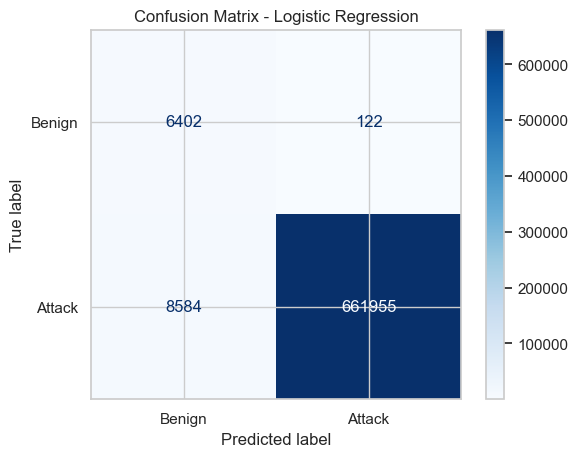

In [13]:
plot_confusion(y_test, y_pred_log, "Confusion Matrix - Logistic Regression")

9. Model 2 - Decision Tree

## Model 2: Decision Tree
A class-weighted decision tree provides a simple nonlinear baseline.

In [14]:
decision_tree = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=10,
    min_samples_leaf=20,
    random_state=42
)

decision_tree.fit(X_train_tree, y_train)

y_pred_dt = decision_tree.predict(X_test_tree)
y_proba_dt = decision_tree.predict_proba(X_test_tree)[:, 1]

dt_results = evaluate_binary_model("Decision Tree", y_test, y_pred_dt, y_proba_dt)
pd.DataFrame([dt_results])

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Decision Tree,0.995904,0.999985,0.995879,0.997928,0.99827,0.999971


In [15]:
print(classification_report(y_test, y_pred_dt, target_names=["Benign", "Attack"], zero_division=0))

              precision    recall  f1-score   support

      Benign       0.70      1.00      0.82      6524
      Attack       1.00      1.00      1.00    670539

    accuracy                           1.00    677063
   macro avg       0.85      1.00      0.91    677063
weighted avg       1.00      1.00      1.00    677063



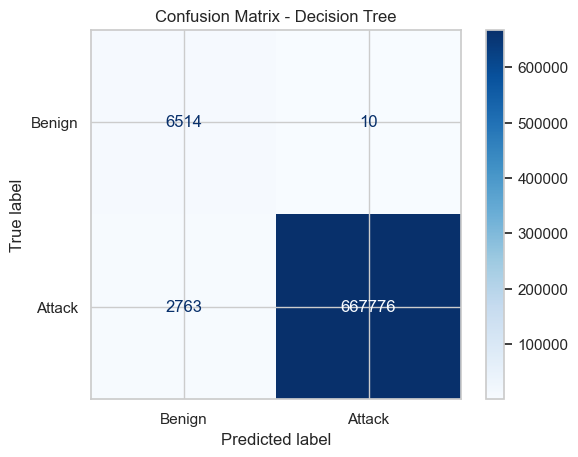

In [16]:
plot_confusion(y_test, y_pred_dt, "Confusion Matrix - Decision Tree")

10. Model 3 - Random Forest

## Model 3: Random Forest
Random Forest is used as a stronger ensemble baseline for binary intrusion detection.

In [17]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

random_forest.fit(X_train_tree, y_train)

y_pred_rf = random_forest.predict(X_test_tree)
y_proba_rf = random_forest.predict_proba(X_test_tree)[:, 1]

rf_results = evaluate_binary_model("Random Forest", y_test, y_pred_rf, y_proba_rf)
pd.DataFrame([rf_results])

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest,0.99936,0.999763,0.999591,0.999677,0.999796,0.999997


In [18]:
print(classification_report(y_test, y_pred_rf, target_names=["Benign", "Attack"], zero_division=0))

              precision    recall  f1-score   support

      Benign       0.96      0.98      0.97      6524
      Attack       1.00      1.00      1.00    670539

    accuracy                           1.00    677063
   macro avg       0.98      0.99      0.98    677063
weighted avg       1.00      1.00      1.00    677063



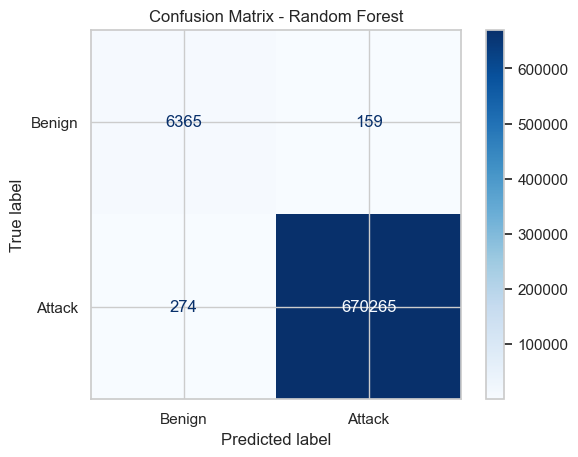

In [19]:
plot_confusion(y_test, y_pred_rf, "Confusion Matrix - Random Forest")

11. Compare baseline results

In [20]:
results_df = pd.DataFrame([log_results, dt_results, rf_results]).sort_values("f1", ascending=False)
results_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
2,Random Forest,0.999360,0.999763,0.999591,0.999677,0.999796,0.999997
1,Decision Tree,0.995904,0.999985,0.995879,0.997928,0.998270,0.999971
0,Logistic Regression,0.987142,0.999816,0.987198,0.993467,0.994067,0.999874


12. ROC and PR curves

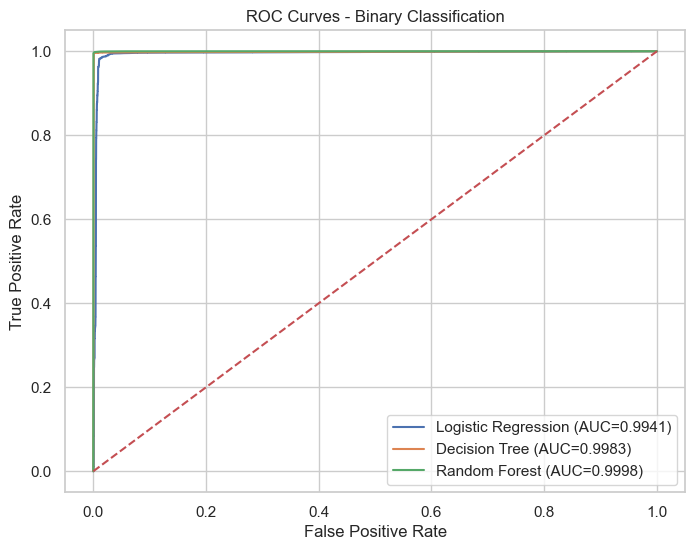

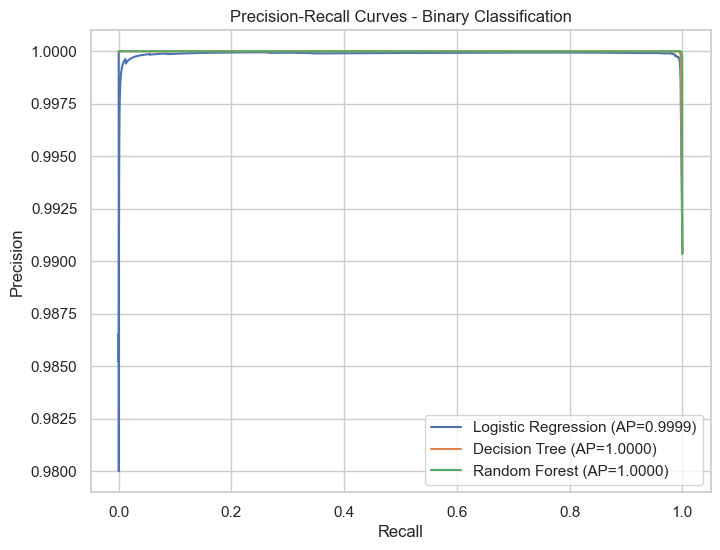

In [21]:
model_curves = {
    "Logistic Regression": y_proba_log,
    "Decision Tree": y_proba_dt,
    "Random Forest": y_proba_rf
}

plot_roc_curves(model_curves, y_test)
plot_pr_curves(model_curves, y_test)

13. Feature importance for tree models

## Feature importance
Tree-based models provide an initial view of which features contribute most to attack detection.

In [22]:
rf_importance = pd.DataFrame({
    "feature": X_train_tree.columns,
    "importance": random_forest.feature_importances_
}).sort_values("importance", ascending=False)

rf_importance.head(20)

,feature,importance
46,ACK Flag Count,0.082700
39,Packet Length Mean,0.079398
38,Packet Length Max,0.078927
51,Average Packet Size,0.071244
45,PSH Flag Count,0.064360
9,Fwd Packet Length Mean,0.061024
58,Subflow Fwd Bytes,0.054549
52,Fwd Segment Size Avg,0.044681
5,Total Length of Fwd Packet,0.039824
64,Fwd Seg Size Min,0.039038


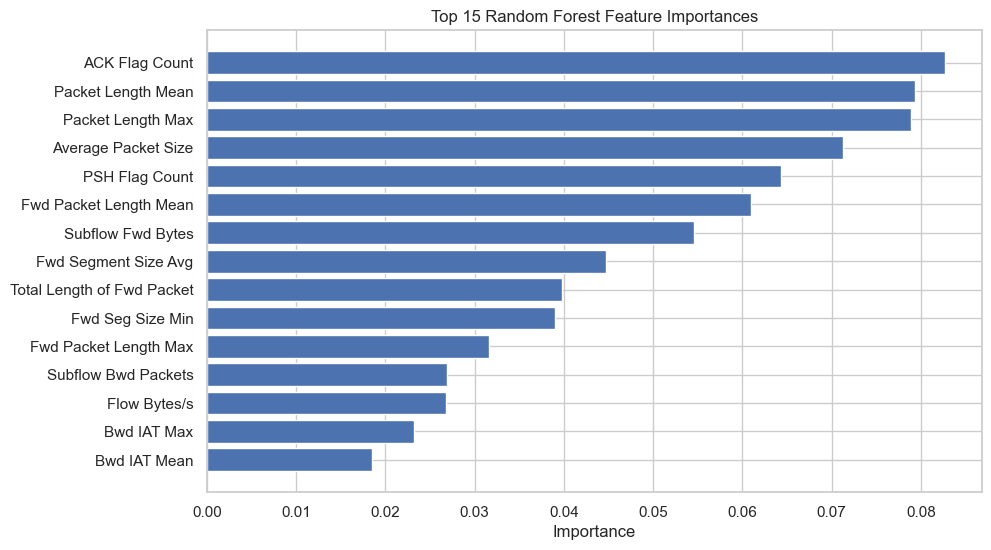

In [23]:
plt.figure(figsize=(10, 6))
top_rf = rf_importance.head(15).sort_values("importance")
plt.barh(top_rf["feature"], top_rf["importance"])
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

In [24]:
dt_importance = pd.DataFrame({
    "feature": X_train_tree.columns,
    "importance": decision_tree.feature_importances_
}).sort_values("importance", ascending=False)

dt_importance.head(15)

,feature,importance
46,ACK Flag Count,0.799497
36,Bwd Packets/s,0.103848
1,Dst Port,0.039217
43,SYN Flag Count,0.013026
7,Fwd Packet Length Max,0.012817
0,Src Port,0.006159
16,Flow Packets/s,0.005829
56,Bwd Bulk Rate Avg,0.005684
61,FWD Init Win Bytes,0.003143
44,RST Flag Count,0.002622


14. Logistic regression coefficients

## Logistic regression coefficients
The absolute coefficient magnitudes provide a rough indication of influential features in the linear baseline.

In [25]:
log_coef_df = pd.DataFrame({
    "feature": X_train_linear.columns,
    "coefficient": log_reg.coef_[0],
    "abs_coefficient": np.abs(log_reg.coef_[0])
}).sort_values("abs_coefficient", ascending=False)

log_coef_df.head(20)

,feature,coefficient,abs_coefficient
4,Total Bwd packets,15.615195,15.615195
45,Fwd Act Data Pkts,-12.676689,12.676689
6,Total Length of Bwd Packet,-5.115014,5.115014
49,Active Max,-4.456208,4.456208
47,Active Mean,4.242511,4.242511
5,Total Length of Fwd Packet,3.512971,3.512971
40,Subflow Fwd Packets,3.305094,3.305094
17,Flow IAT Mean,-3.038099,3.038099
3,Total Fwd Packet,-2.962375,2.962375
35,PSH Flag Count,-2.211055,2.211055


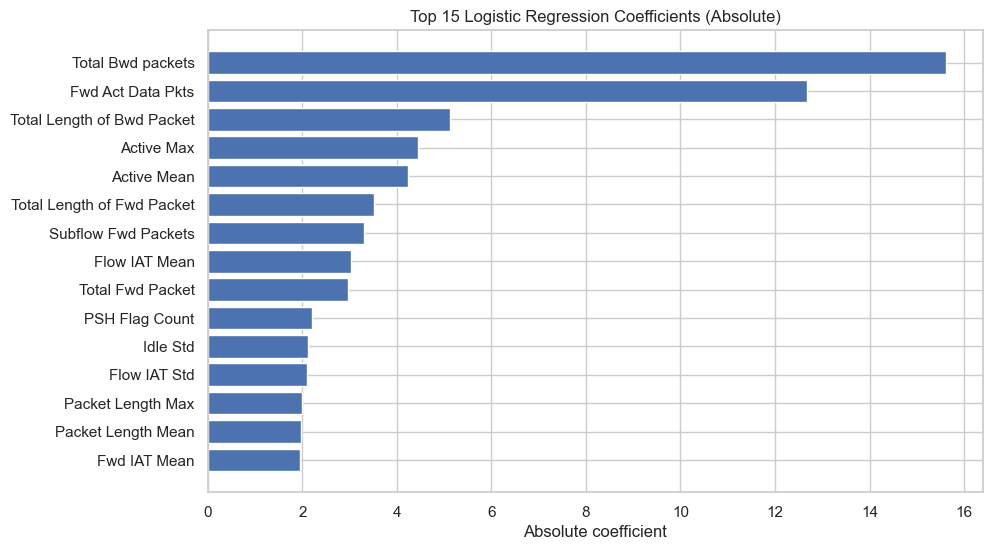

In [26]:
plt.figure(figsize=(10, 6))
top_log = log_coef_df.head(15).sort_values("abs_coefficient")
plt.barh(top_log["feature"], top_log["abs_coefficient"])
plt.title("Top 15 Logistic Regression Coefficients (Absolute)")
plt.xlabel("Absolute coefficient")
plt.show()

15. Threshold discussion for logistic regression

## Threshold sensitivity
Because the dataset is highly imbalanced, the default 0.5 threshold may not be optimal. This section compares a lower threshold for the logistic regression model.

In [27]:
threshold = 0.3
y_pred_log_03 = (y_proba_log >= threshold).astype(int)

log_results_03 = evaluate_binary_model(
    f"Logistic Regression (threshold={threshold})",
    y_test,
    y_pred_log_03,
    y_proba_log
)

pd.DataFrame([log_results, log_results_03])

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.987142,0.999816,0.987198,0.993467,0.994067,0.999874
1,Logistic Regression (threshold=0.3),0.991948,0.999730,0.992138,0.995919,0.994067,0.999874


In [28]:
print(classification_report(y_test, y_pred_log_03, target_names=["Benign", "Attack"], zero_division=0))

              precision    recall  f1-score   support

      Benign       0.55      0.97      0.70      6524
      Attack       1.00      0.99      1.00    670539

    accuracy                           0.99    677063
   macro avg       0.77      0.98      0.85    677063
weighted avg       1.00      0.99      0.99    677063



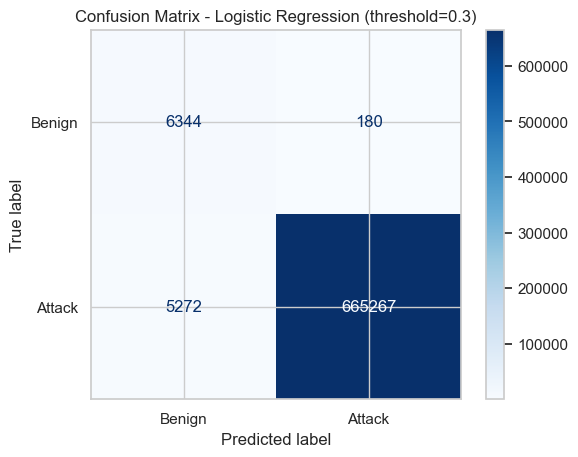

In [29]:
plot_confusion(y_test, y_pred_log_03, f"Confusion Matrix - Logistic Regression (threshold={threshold})")

16. Summary table with ranking

In [30]:
summary_df = pd.DataFrame([log_results, dt_results, rf_results, log_results_03]).sort_values(
    ["f1", "pr_auc", "roc_auc"], ascending=False
).reset_index(drop=True)

summary_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest,0.999360,0.999763,0.999591,0.999677,0.999796,0.999997
1,Decision Tree,0.995904,0.999985,0.995879,0.997928,0.998270,0.999971
2,Logistic Regression (threshold=0.3),0.991948,0.999730,0.992138,0.995919,0.994067,0.999874
3,Logistic Regression,0.987142,0.999816,0.987198,0.993467,0.994067,0.999874


17. Export results

## Export model results and models for application

In [31]:
REPORT_DIR = Path("../reports/results")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

summary_df.to_csv(REPORT_DIR / "binary_model_comparison.csv", index=False)
rf_importance.to_csv(REPORT_DIR / "binary_random_forest_importance.csv", index=False)
dt_importance.to_csv(REPORT_DIR / "binary_decision_tree_importance.csv", index=False)
log_coef_df.to_csv(REPORT_DIR / "binary_logistic_coefficients.csv", index=False)

print("Binary classification results exported.")

Binary classification results exported.


In [32]:
from pathlib import Path
import pandas as pd

REPORT_DIR = Path("../reports/results")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

pd.DataFrame({"feature": X_train_tree.columns}).to_csv(
    REPORT_DIR / "binary_rf_features.csv",
    index=False
)

print("Saved binary_rf_features.csv")

Saved binary_rf_features.csv


In [33]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(random_forest, MODEL_DIR / "binary_random_forest.joblib")
print("Saved binary_random_forest.joblib")

Saved binary_random_forest.joblib


18. Final summary

## Summary of findings

The binary classification task is highly imbalanced, with attack traffic representing the overwhelming majority of observations. As expected, this makes plain accuracy an insufficient evaluation metric. The comparison of baseline models therefore focused on class-sensitive metrics including precision, recall, F1-score, ROC-AUC, and PR-AUC.

The class-weighted logistic regression provided an interpretable linear baseline, while the decision tree and random forest captured nonlinear relationships in the flow-based network features. The random forest is expected to perform more strongly overall, although the exact trade-off between attack detection and benign-traffic recognition should be assessed through the confusion matrix and class-specific metrics.

These baseline results establish a benchmark for the next stage of the project, where multiclass attack classification will be explored.

### Interpretation note

Given the extreme prevalence of attack traffic in the binary target, a classifier can achieve very high accuracy while still performing poorly on the minority benign class. For this reason, the confusion matrix, PR-AUC, and class-specific precision and recall are essential for meaningful evaluation.

### Conclusion

The very high binary classification performance suggests that benign and attack traffic are highly separable in the available feature space. However, such near-perfect results should be interpreted cautiously, as controlled or benchmark cybersecurity datasets may contain patterns that are easier to learn than those found in noisy real-world deployment environments.

The binary classification results indicate that CICIoMT2024 is highly separable at the benign-versus-attack level. While the class-weighted logistic regression provided a strong linear baseline, both tree-based models performed better, with Random Forest achieving the strongest overall balance across precision, recall, F1-score, ROC-AUC, and PR-AUC. Importantly, the Random Forest model maintained very strong benign-class performance despite the extreme class imbalance, suggesting that flow-level traffic characteristics and TCP-flag behaviour provide substantial discriminatory power for intrusion detection in this dataset.